<a href="https://colab.research.google.com/github/Sangam1293/MZE/blob/main/Hospital_Readmission_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of patients
n_patients = 1000

# Generate synthetic data
data = {
    'patient_id': np.arange(n_patients),
    'age': np.random.randint(18, 90, n_patients),
    'gender': np.random.choice(['Male', 'Female'], n_patients),
    'diagnosis_code': np.random.choice([f'ICD-{i}' for i in range(1, 11)], n_patients),
    'systolic_bp': np.random.randint(90, 180, n_patients),
    'diastolic_bp': np.random.randint(60, 120, n_patients),
    'heart_rate': np.random.randint(50, 110, n_patients),
    'prior_visits': np.random.randint(0, 10, n_patients),
    'readmitted_30_days': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]) # 30% readmission rate
}

df = pd.DataFrame(data)
display(df.head())

,patient_id,age,gender,diagnosis_code,systolic_bp,diastolic_bp,heart_rate,prior_visits,readmitted_30_days
0,0,69,Male,ICD-8,151,100,89,8,0
1,1,32,Male,ICD-7,122,64,62,1,0
2,2,89,Female,ICD-9,174,117,87,7,0
3,3,78,Male,ICD-4,124,60,67,8,0
4,4,38,Male,ICD-2,141,76,51,9,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop(['patient_id', 'readmitted_30_days'], axis=1)
y = df['readmitted_30_days']

# Identify categorical and numerical features
categorical_features = ['gender', 'diagnosis_code']
numerical_features = ['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'prior_visits']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Original X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Apply preprocessing to training data (fit and transform)
X_train_processed = preprocessor.fit_transform(X_train)

# Apply preprocessing to test data (transform only)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X shape: (1000, 7)
X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)
Processed X_train shape: (800, 17)
Processed X_test shape: (200, 17)


In [4]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with L2 regularization
# C is the inverse of regularization strength; smaller values specify stronger regularization.
# Default penalty is 'l2'.
model = LogisticRegression(random_state=42, solver='liblinear', C=1.0)

# Train the model
model.fit(X_train_processed, y_train)

print("Model training complete!")
print(f"Number of features used by the model: {model.n_features_in_}")
print(f"Model coefficients (first 10): {model.coef_[0][:10]}")
print(f"Model intercept: {model.intercept_[0]}")

Model training complete!
Number of features used by the model: 17
Model coefficients (first 10): [ 0.09754202 -0.01053155  0.07949032  0.01149622  0.02331845 -0.35129967
 -0.1904546   0.21118847  0.16702015 -0.27399094]
Model intercept: -0.5417542726319622


ROC-AUC Score: 0.4783

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.83       141
           1       0.00      0.00      0.00        59

    accuracy                           0.70       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.50      0.70      0.58       200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x600 with 0 Axes>

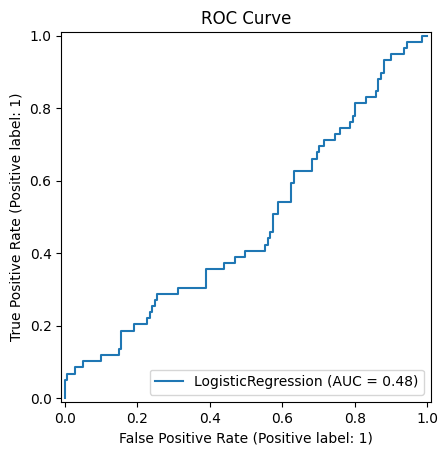

In [8]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on the test set
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Predict classes on the test set (using default threshold of 0.5)
y_pred = model.predict(X_test_processed)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test_processed, y_test)
plt.title('ROC Curve')
plt.show()

Model training complete with balanced class weights!

ROC-AUC Score (with balanced class weights): 0.4769

Classification Report (with balanced class weights):
              precision    recall  f1-score   support

           0       0.65      0.44      0.52       141
           1       0.24      0.42      0.31        59

    accuracy                           0.43       200
   macro avg       0.44      0.43      0.41       200
weighted avg       0.53      0.43      0.46       200



<Figure size 800x600 with 0 Axes>

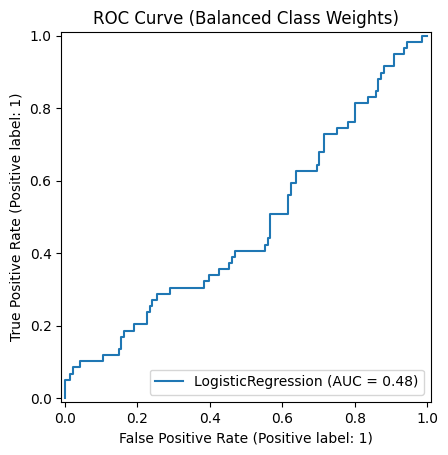

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

# Initialize the Logistic Regression model with L2 regularization and balanced class weights
model_balanced = LogisticRegression(random_state=42, solver='liblinear', C=1.0, class_weight='balanced')

# Train the model with balanced class weights
model_balanced.fit(X_train_processed, y_train)

print("Model training complete with balanced class weights!")

# Re-evaluate the model with balanced class weights

# Predict probabilities on the test set
y_pred_proba_balanced = model_balanced.predict_proba(X_test_processed)[:, 1]

# Predict classes on the test set (using default threshold of 0.5)
y_pred_balanced = model_balanced.predict(X_test_processed)

# Calculate ROC-AUC score
roc_auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)
print(f"\nROC-AUC Score (with balanced class weights): {roc_auc_balanced:.4f}")

# Display classification report
print("\nClassification Report (with balanced class weights):")
print(classification_report(y_test, y_pred_balanced))

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(model_balanced, X_test_processed, y_test)
plt.title('ROC Curve (Balanced Class Weights)')
plt.show()